(mmm_experiment_designer)=
# Experiment Designer: Posterior-Aware Lift Test Design

:::{warning}
This is **experimental functionality**. The current implementation works at the national level but does not yet support geo-level experiment design. We are very interested in hearing from users — would this be useful in your workflow? What directions should we prioritise? Please open an issue or start a discussion on the [PyMC-Marketing GitHub](https://github.com/pymc-labs/pymc-marketing) with your feedback.
:::

You've fitted a Marketing Mix Model — now what? You know you should run a lift test to validate the model, but you face a set of awkward design questions:

- **Which channel** should you test?
- **At what spend level** — where on the saturation curve should the test probe?
- **For how long** — what duration balances statistical power against cost?
- **What is the expected lift**, given all the uncertainty in the model?

Traditional experiment design tools (e.g. GeoLift) require the practitioner to *guess* the expected effect size up front — the very quantity the experiment is supposed to measure. This creates a chicken-and-egg problem.

The `ExperimentDesigner` sidesteps this by using the fitted MMM's posterior distribution directly. The posterior already encodes what the model believes about each channel's response function, including its uncertainty. For every candidate experiment (channel × spend change × duration), the designer pushes each posterior draw through the adstock and saturation transforms to produce a **distribution of predicted lifts** — not a single point estimate. From that distribution it computes **Bayesian assurance** (posterior-predictive power) and ranks candidates by a composite score that balances informativeness, detectability, and cost.

:::{tip}
If you want to jump straight to the code, skip ahead to the [Workflow](#workflow) section.
:::

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from pymc_marketing.mmm.experiment_design import (
    ExperimentDesigner,
    generate_experiment_fixture,
)

%config InlineBackend.figure_format = "retina"

FIG_WIDTH = 10
FIG_HEIGHT = 4

CHANNEL_COLORS = {"tv": "C0", "search": "C1", "social": "C2"}

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/Users/benjamv/mambaforge/envs/pymc-marketing-dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## How It Works

This section explains the key ideas behind the `ExperimentDesigner`. Understanding these concepts will make the workflow outputs much easier to interpret.

### The Core Insight: Using the Posterior Instead of Guessing

Standard power analysis requires a **minimum detectable effect (MDE)** — the analyst must specify the effect size they expect the experiment to find. But if you already knew the effect size, you wouldn't need the experiment.

The `ExperimentDesigner` resolves this by using the fitted MMM's posterior. Each posterior draw defines a complete channel response function (adstock decay $\alpha$, saturation half-life $\lambda$, channel scale $\beta$). For a given spend change, every draw implies a different predicted lift. The result is a **posterior distribution of predicted lifts** rather than a single number.

This means the designer doesn't need you to guess anything — it inherits the model's beliefs *and* uncertainties about each channel. Channels the model is confident about will yield tight lift distributions; channels with wide posteriors will produce spread-out lift distributions that honestly reflect the risk that the true effect might be small.

### Adstock-Aware Lift Prediction

A spend change doesn't produce its full effect overnight. In an MMM with geometric adstock, the *effective* (adstocked) spend ramps up over several weeks before reaching steady state. The designer models this ramp explicitly so that predicted lifts are realistic for short experiments.

The lift prediction pipeline works as follows:

1. **Steady-state adstocked spend.** Given current weekly spend $x$ and adstock decay $\alpha$ with maximum lag $L$, the steady-state adstocked spend is

$$x_{\text{ss}} = x \cdot \frac{1 - \alpha^{L}}{1 - \alpha}$$

   (For normalised adstock where the weights sum to 1, $x_{\text{ss}} = x$.)

2. **Adstock ramp.** When spend changes at week $t = 0$, the adstocked spend doesn't jump to the new steady state immediately. At week $t$ the partial geometric sum is

$$r_t = \frac{1 - \alpha^{t+1}}{1 - \alpha}$$

   The **ramp fraction** $r_t / S$ tells us what share of the steady-state effect has been reached by week $t$. Channels with slow decay (high $\alpha$) ramp slowly and need longer experiments.

3. **Effective spend per week.** Combining the baseline and the ramped change:

$$x_{\text{eff},t} = x_{\text{ss}} + \Delta x \cdot r_t$$

   where $\Delta x$ is the absolute spend change.

4. **Weekly lift through saturation.** Each week's lift is the difference between the response at the new effective spend and the baseline response:

$$\ell_t = f(x_{\text{eff},t}) - f(x_{\text{ss}})$$

   where $f$ is the logistic saturation function $f(x) = \beta\,(1 - e^{-\lambda x}) / (1 + e^{-\lambda x})$.

5. **Total lift.** The cumulative lift over a $T$-week experiment is $L = \sum_{t=0}^{T-1} \ell_t$. Because every quantity above depends on the posterior draw $(\lambda, \beta, \alpha)$, we obtain a full posterior distribution of $L$.

### Bayesian Assurance (Posterior-Predictive Power)

With a posterior distribution of predicted lifts in hand, the next question is: *if the true effect is drawn from this posterior, how likely is the experiment to detect it?*

Traditional power analysis answers this for a single assumed effect size $\theta_0$:

$$\text{Power}(\theta_0) = P\!\bigl(\text{reject } H_0 \mid \theta = \theta_0\bigr)$$

**Bayesian assurance** averages power over the entire posterior, weighting each possible effect size by how plausible the model considers it:

$$\text{Assurance} = \mathbb{E}_{\theta \sim \text{posterior}}\!\left[\text{Power}(\theta)\right]$$

In practice, this is computed per posterior draw. For each draw $i$:

1. Compute the predicted cumulative lift $L_i$.
2. Derive the non-centrality parameter: $\text{ncp}_i = |L_i| \,/\, \sigma_d$, where $\sigma_d$ is the cumulative measurement noise over $T$ weeks (see below).
3. Evaluate two-sided power via the normal CDF.

The assurance is then the mean of per-draw power values across all posterior draws.

**Measurement noise with autocorrelation correction.** The cumulative noise $\sigma_d$ starts from the per-week residual standard deviation $\sigma_\varepsilon$ of the fitted MMM. Under IID residuals this would simply be $\sigma_\varepsilon \sqrt{T}$, but time series residuals are typically positively autocorrelated. The designer estimates the lag-1 autocorrelation $\rho$ of the residuals and applies the AR(1) variance inflation:

$$\sigma_d = \sigma_\varepsilon \sqrt{T \cdot \frac{1 + \rho}{1 - \rho}}$$

For $\rho = 0$ this reduces to the IID formula. For $\rho = 0.3$ (moderate autocorrelation), the correction inflates $\sigma_d$ by a factor of $\approx 1.36$, producing more conservative — and more honest — assurance estimates.

This produces natural behaviour:
- **Well-identified channels** with large posterior effects yield high assurance.
- **Uncertain channels** produce a spread of power values — the assurance honestly reflects the risk that the true effect may be too small to detect.
- **Posterior mass near zero** pulls assurance down, correctly signalling that the experiment may fail.

### Scoring and Ranking

Not every high-assurance experiment is worth running. A go-dark test on your largest channel might have excellent power but enormous opportunity cost. The designer ranks candidates by a **weighted composite score** that balances two concerns:

| Dimension | Default weight | What it captures |
|-----------|---------------|------------------|
| **Assurance** | 0.50 | Experiments likely to produce a statistically detectable signal |
| **Cost efficiency** | 0.50 | Assurance per unit of spend disruption (see note below) |

Each dimension is min-max normalised to $[0, 1]$ across all candidates, then combined via a weighted sum. Candidates are sorted by score in descending order.

:::{note}
**How cost efficiency is computed.** Cost efficiency is defined as $\text{assurance}\;/\;|\text{net cost}|$, where net cost is the weekly spend change multiplied by the experiment duration, expressed in model-scale units. The absolute value means a \$10k spend increase and a \$10k spend decrease are treated as equally disruptive. This metric does not account for the sign of the cost (savings vs. additional spend), nor does it factor in the value of the expected lift on the outcome variable. It answers a narrow question: *how much operational disruption must I tolerate to get a detectable signal?* — not whether the experiment is profitable or which direction of spend change is preferable.
:::

Before scoring, a **signal-to-noise ratio (SNR) pre-filter** removes candidates whose expected lift is too small relative to measurement noise. This avoids wasting ranking capacity on experiments that have little chance of succeeding regardless of other factors.

The relative weight of the two dimensions can be adjusted via the `score_weights` parameter (e.g. `{"assurance": 0.8, "cost_efficiency": 0.2}` to prioritise detectability over cost).

### Null-Confirmation Candidates

If the model's posterior for a channel's contribution is concentrated near zero, Bayesian assurance will be low regardless of experiment duration — the model believes there's nothing to detect. Such channels are structurally deprioritised by the scoring system.

However, confirming that a channel truly has no effect is itself valuable: it can justify reallocating budget away from ineffective spend. The designer identifies these **null-confirmation candidates** and reports them alongside the recommendations, so they aren't silently ignored.

(workflow)=
## Workflow

With the concepts established, we now walk through the full workflow using a synthetic fixture with three channels.

### Step 1: Load a Fixture (or Use a Fitted MMM)

The `ExperimentDesigner` can be created from:
- A **fitted MMM** via `ExperimentDesigner(mmm)` — the primary workflow
- A **saved InferenceData** via `ExperimentDesigner.from_idata(idata)` — for demos and testing

Here we generate a synthetic fixture with known ground-truth parameters for three channels:

| Channel | λ (saturation efficiency) | β (scale) | α (adstock decay) |
|---------|--------------------------|-----------|--------------------|
| TV      | 0.5 (slow saturation)     | 3.0       | 0.7 (slow decay)   |
| Search  | 2.0 (fast saturation)     | 1.5       | 0.3 (fast decay)   |
| Social  | 1.0 (moderate)            | 0.8       | 0.5 (moderate)     |

In [2]:
idata = generate_experiment_fixture(
    channels=["tv", "search", "social"],
    true_params={
        "tv": {"lam": 0.5, "beta": 3.0, "alpha": 0.7},
        "search": {"lam": 2.0, "beta": 1.5, "alpha": 0.3},
        "social": {"lam": 1.0, "beta": 0.8, "alpha": 0.5},
    },
    fit_model=False,
    seed=42,
)

designer = ExperimentDesigner.from_idata(idata)
print(f"Channels: {designer.channel_columns}")
print(f"Posterior draws: {designer.n_draws}")
print(f"Adstock l_max: {designer.l_max}, normalize: {designer.normalize}")

Channels: [np.str_('tv'), np.str_('search'), np.str_('social')]
Posterior draws: 4000
Adstock l_max: 8, normalize: True


In [3]:
rho = designer._residual_autocorr
sigma = designer._residual_std
sigma_iid_8 = sigma * np.sqrt(8)
sigma_ar1_8 = designer._effective_sigma(8)
correction = sigma_ar1_8 / sigma_iid_8

print(f"Residual std (per week):       {sigma:.4f}")
print(f"Residual autocorrelation (ρ):  {rho:.3f}")
print(f"IID sigma (T=8 weeks):         {sigma_iid_8:.4f}")
print(f"AR(1)-corrected sigma (T=8):   {sigma_ar1_8:.4f}")
print(f"Correction factor:             {correction:.2f}x")

Residual std (per week):       0.0337
Residual autocorrelation (ρ):  0.123
IID sigma (T=8 weeks):         0.0952
AR(1)-corrected sigma (T=8):   0.1077
Correction factor:             1.13x


The designer estimates the lag-1 autocorrelation $\rho$ of the MMM residuals and inflates the cumulative measurement noise accordingly. With positive autocorrelation, the IID formula $\sigma_\varepsilon \sqrt{T}$ underestimates the true noise — the AR(1) correction $\sqrt{(1 + \rho)/(1 - \rho)}$ compensates, producing more conservative and honest assurance estimates.

### Step 2: Inspect Posterior Uncertainty

Before recommending experiments, we examine two diagnostic questions:

1. **How correlated is spend across channels?** High pairwise correlations make it difficult for the model to attribute the outcome to individual channels — this is the identification problem. Channels with high spend correlation are prime candidates for a lift test because an experiment breaks the correlation by construction.
2. **How uncertain is the model about each channel's response function?** Wide posteriors on the saturation parameters ($\lambda$, $\beta$) or the adstock decay ($\alpha$) indicate channels where the model has not yet learned the true response. These are the channels where an experiment would be most informative.

:::{tip}
For a quick programmatic summary, `designer.plot_channel_diagnostics()` produces a compact bar-chart overview of all scoring dimensions.
:::

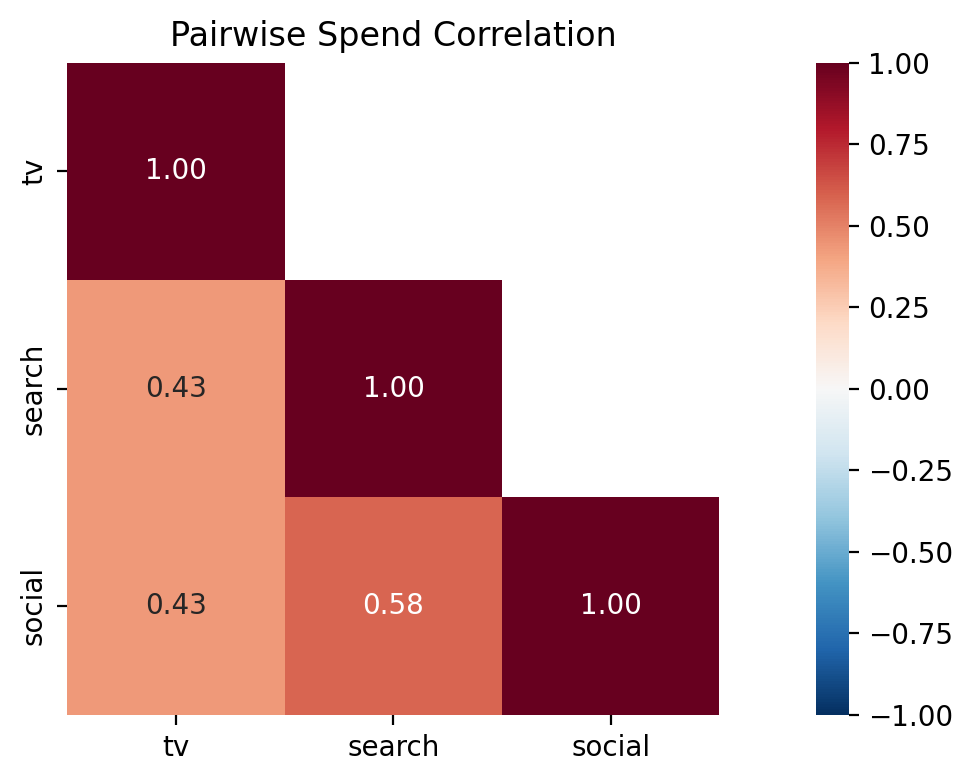

In [4]:
corr_df = designer._spend_correlation
mask = np.triu(np.ones_like(corr_df, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))
sns.heatmap(
    corr_df,
    mask=mask,
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    center=0,
    cmap="RdBu_r",
    square=True,
    ax=ax,
)
ax.set_title("Pairwise Spend Correlation")
fig.tight_layout()
plt.show()

**Caption:** Pairwise Pearson correlation of weekly spend across channels. Values near +1 indicate channels whose spend moves together, making it harder for the model to attribute the outcome to either channel individually. High-correlation pairs are strong candidates for a lift test.

Next, we examine what the model believes about each channel's response function. The saturation parameters $\lambda$ (half-life) and $\beta$ (scale) jointly determine the shape of the diminishing-returns curve. A KDE contour plot in this parameter space reveals both the uncertainty and any degeneracies — channels with tight, well-separated contours are well identified, while broad or overlapping contours indicate the model struggles to pin down the response.

/var/folders/pd/p2qnky2x3xl4w3mgc4lct2200000gn/T/ipykernel_38967/650838774.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


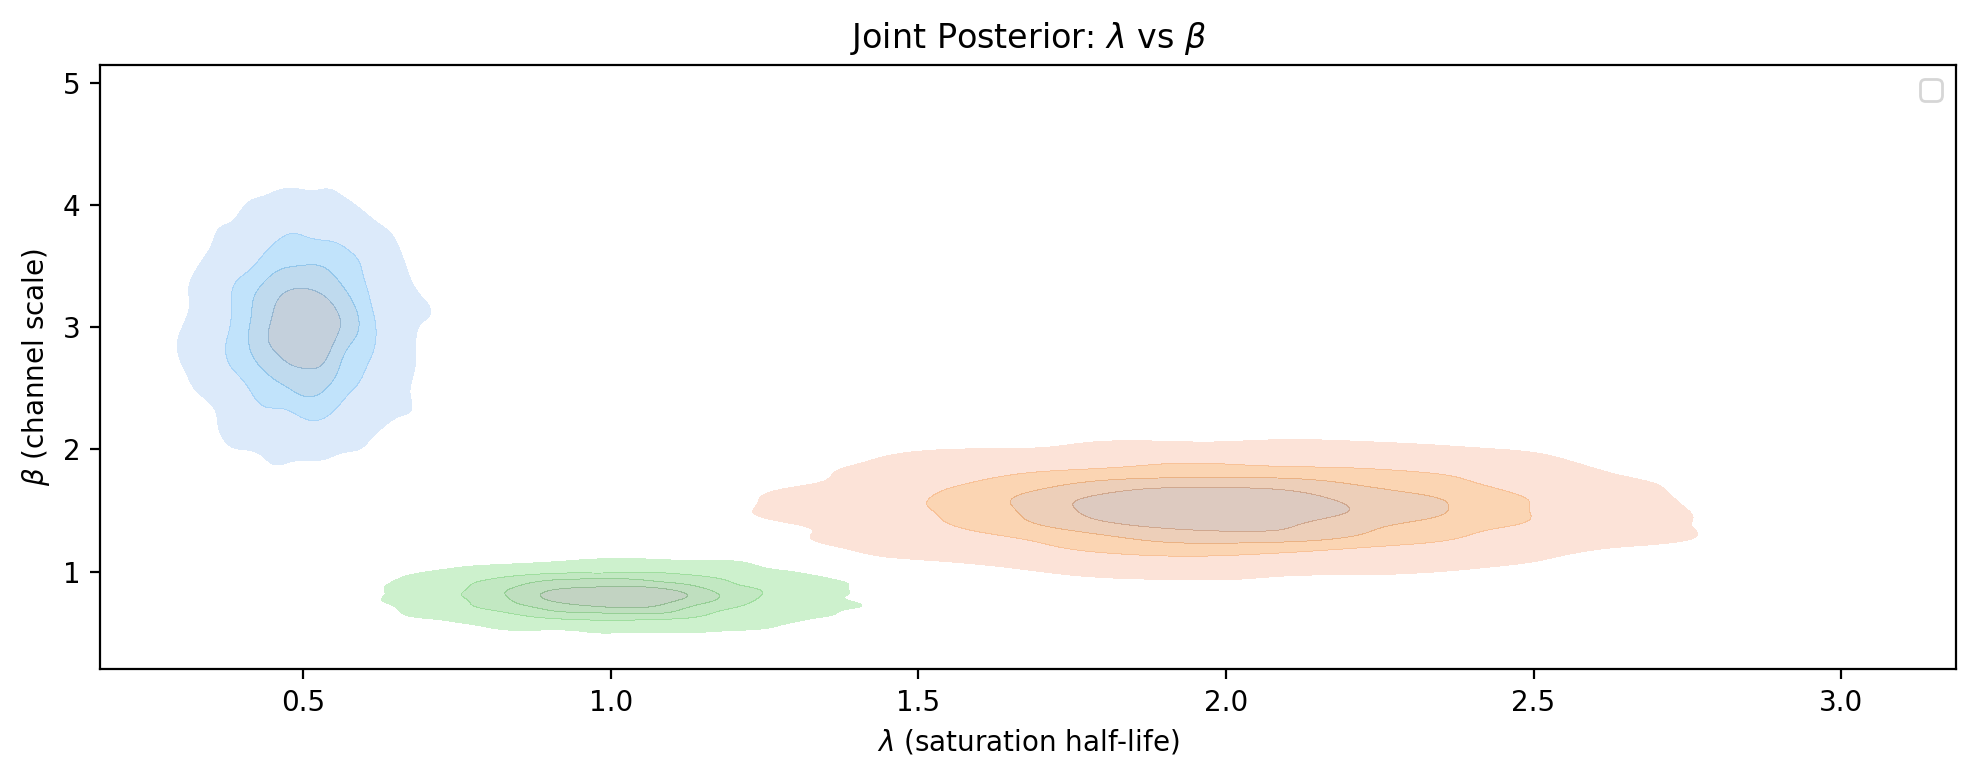

In [5]:
fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))
stacked = designer._posterior.stack(sample=("chain", "draw"))
for ch in designer.channel_columns:
    lam = stacked["saturation_lam"].sel(channel=ch).values
    beta = stacked["saturation_beta"].sel(channel=ch).values
    sns.kdeplot(
        x=lam,
        y=beta,
        ax=ax,
        color=CHANNEL_COLORS[ch],
        label=ch,
        levels=5,
        fill=True,
        alpha=0.3,
    )
ax.set_xlabel(r"$\lambda$ (saturation half-life)")
ax.set_ylabel(r"$\beta$ (channel scale)")
ax.set_title(r"Joint Posterior: $\lambda$ vs $\beta$")
ax.legend()
fig.tight_layout()
plt.show()

**Caption:** Joint posterior density of saturation parameters $\lambda$ (half-life) and $\beta$ (channel scale) for each channel. Tighter contours indicate better-identified channels; broad or elongated contours suggest the model cannot distinguish between different $\lambda$-$\beta$ combinations, making the channel a strong candidate for a lift test.

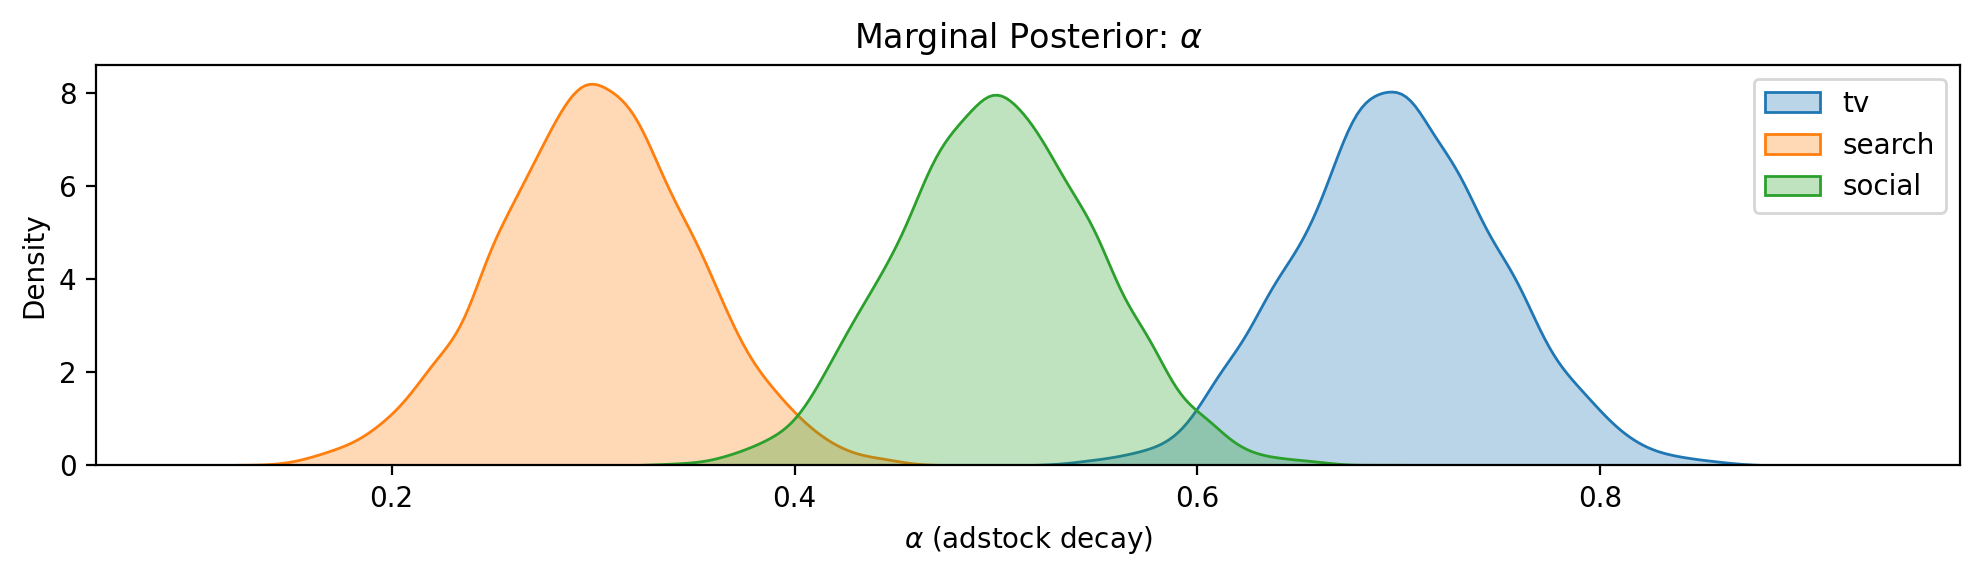

In [6]:
fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT * 0.75))
stacked = designer._posterior.stack(sample=("chain", "draw"))
for ch in designer.channel_columns:
    alpha_samples = stacked["adstock_alpha"].sel(channel=ch).values
    sns.kdeplot(
        alpha_samples, ax=ax, color=CHANNEL_COLORS[ch], label=ch, fill=True, alpha=0.3
    )
ax.set_xlabel(r"$\alpha$ (adstock decay)")
ax.set_ylabel("Density")
ax.set_title(r"Marginal Posterior: $\alpha$")
ax.legend()
fig.tight_layout()
plt.show()

**Caption:** Marginal posterior density of the adstock decay parameter $\alpha$ for each channel. Higher $\alpha$ means slower decay and longer carryover, which affects both the adstock ramp fraction and the minimum experiment duration needed to capture the full effect.

### Step 3: Visualise Saturation Curves

The saturation curve reveals where each channel sits on its diminishing-returns curve and how uncertain the model is about the shape. Channels whose HDI band is wide at the operating point are prime candidates for a lift test.

The x-axis is labelled **Adstocked Spend** rather than raw weekly spend. In the MMM, raw spend is first transformed by the adstock function (which accumulates decayed spend from previous weeks) before being passed through the saturation curve. What the saturation function "sees" is this accumulated value — the steady-state adstocked spend. This is the natural scale for the saturation curve because it's the actual input to the diminishing-returns function. The vertical dashed line marks the current adstocked spend (i.e. the operating point), and the dotted lines show where candidate spend changes would land on the curve.

Note that each channel's adstock behaviour is different — a channel with slow decay ($\alpha = 0.7$) accumulates much more carryover than one with fast decay ($\alpha = 0.3$), so their adstocked spend values can differ substantially even if their raw weekly spends are similar. The [Adstock Ramp-up](#adstock-ramp-up) plot later in this notebook visualises this decay behaviour directly.

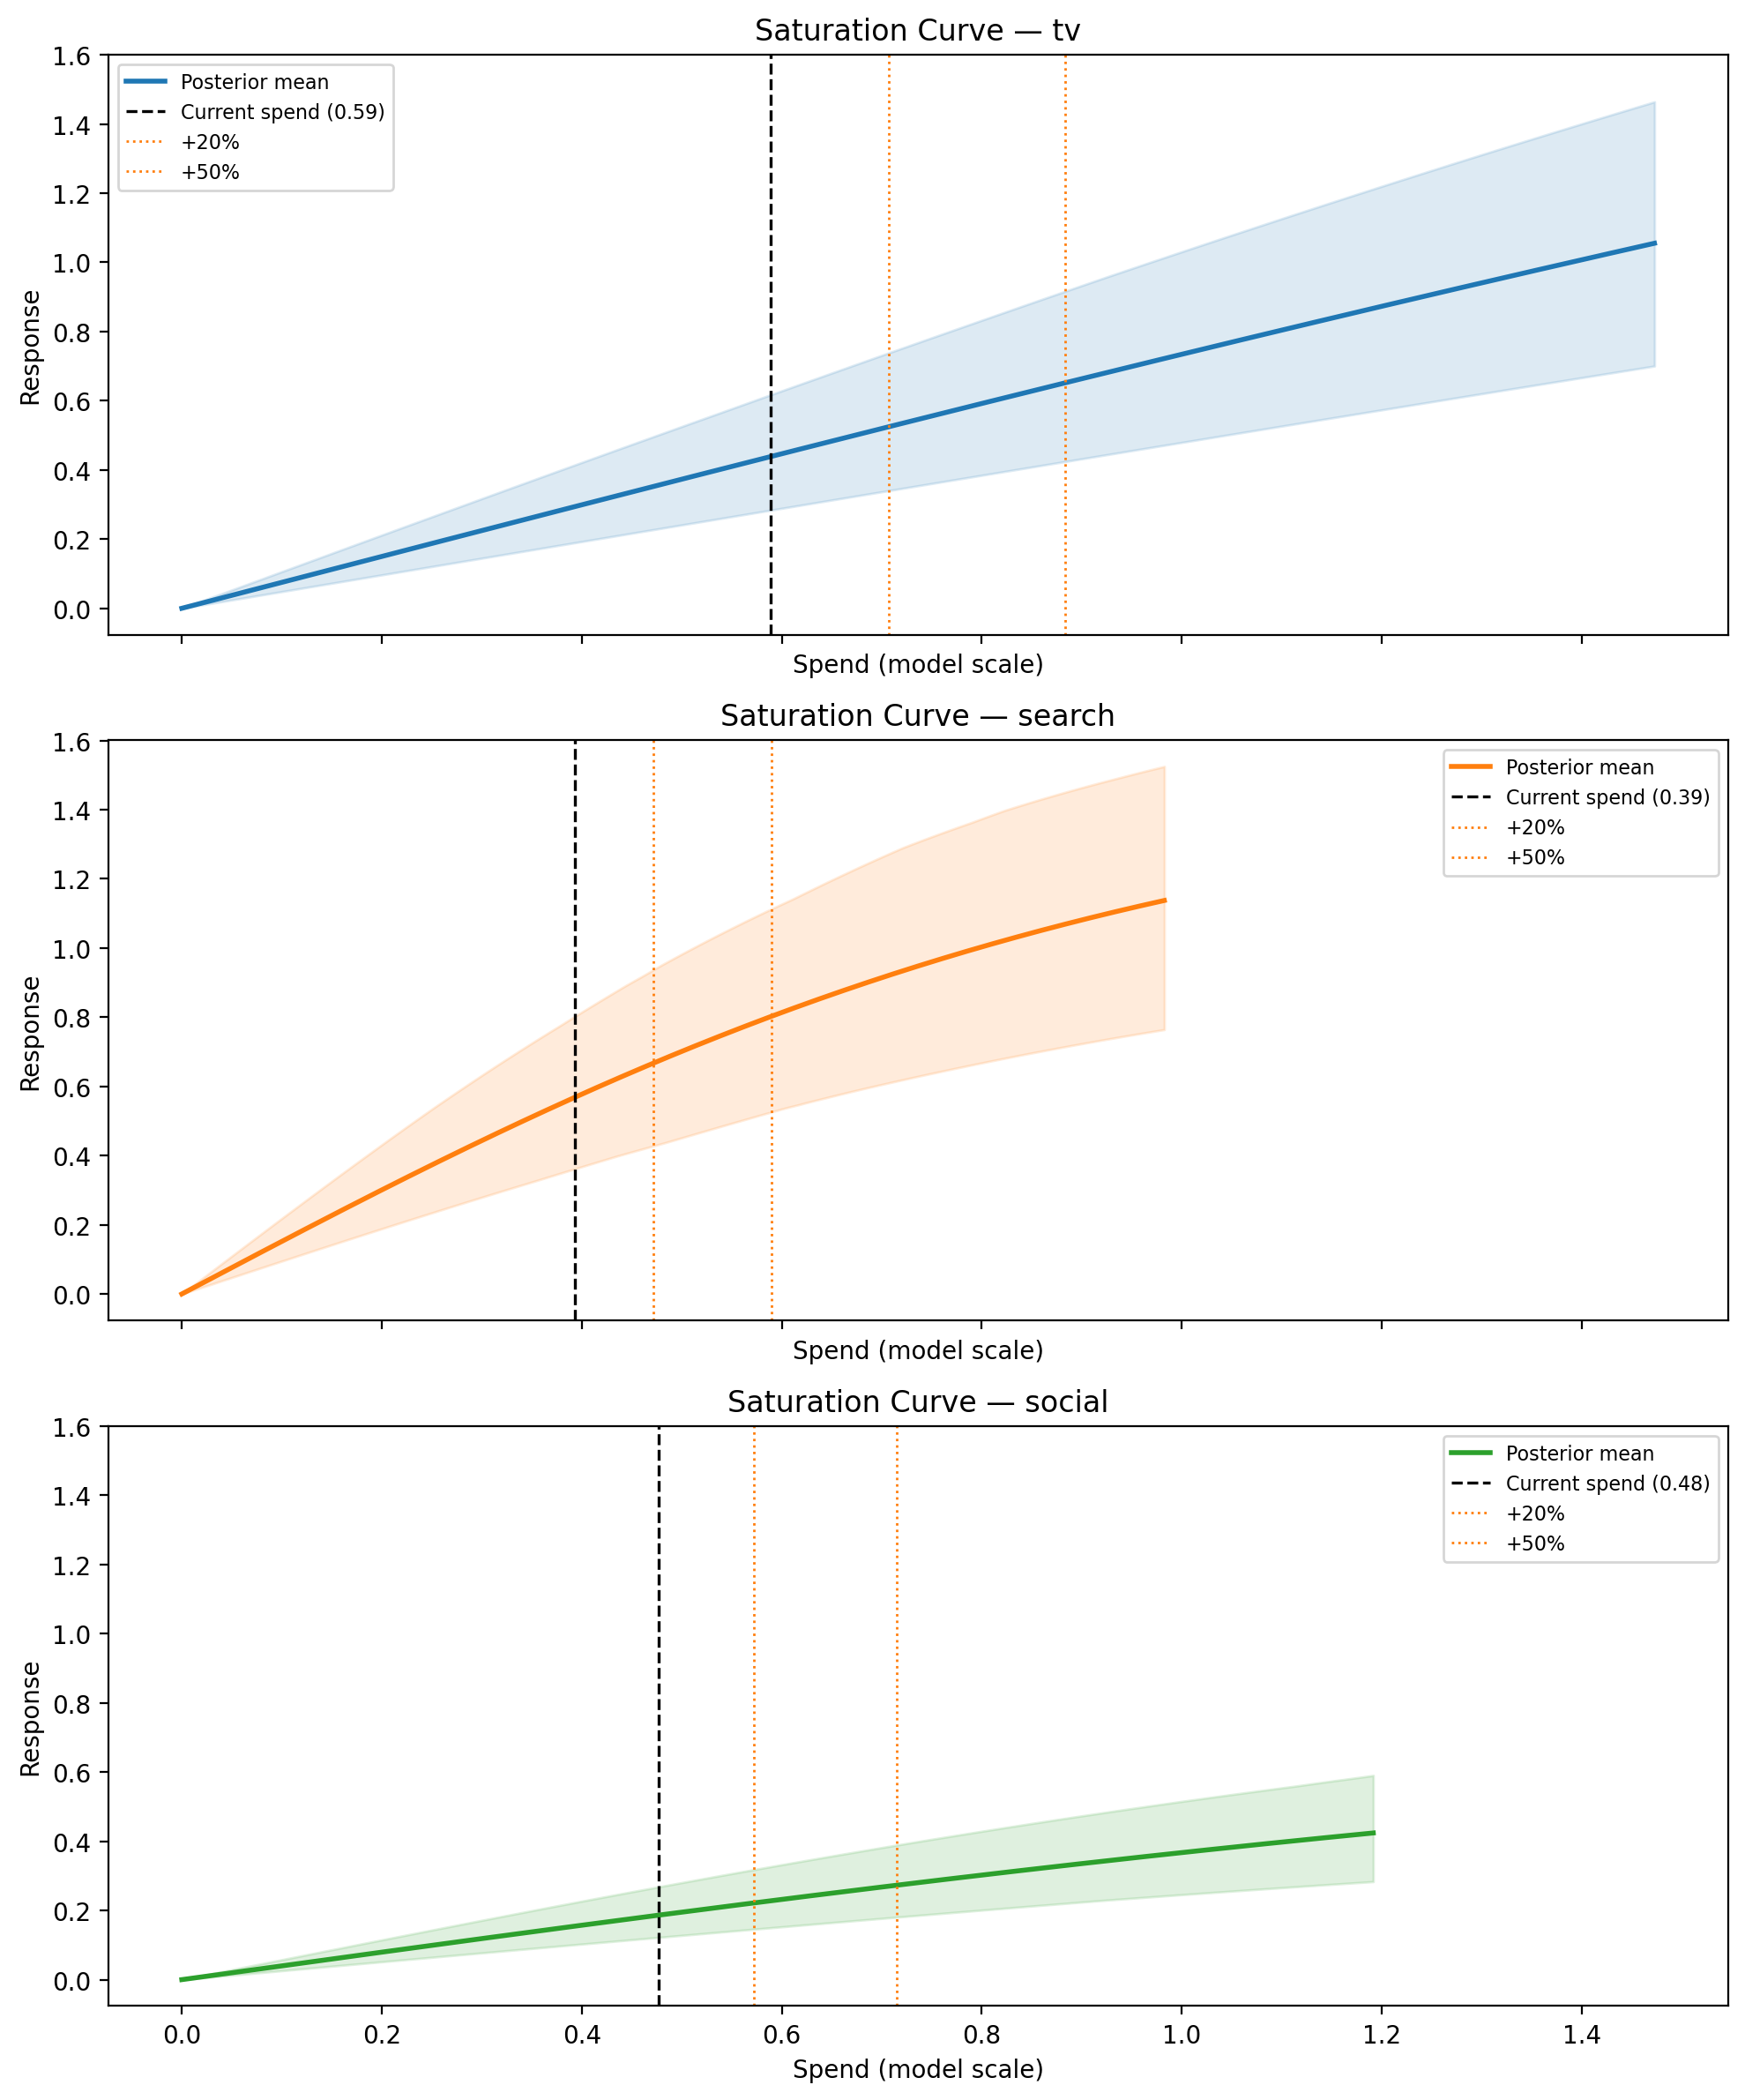

In [7]:
fig, axes = plt.subplots(
    3, 1, figsize=(FIG_WIDTH, FIG_HEIGHT * 3), sharex=True, sharey=True
)

for ax, channel in zip(axes, designer.channel_columns, strict=True):
    designer.plot_saturation_curve(
        channel, spend_levels=[0.2, 0.5], ax=ax, color=CHANNEL_COLORS[channel]
    )

fig.tight_layout()
plt.show()

**Caption:** Posterior saturation curves for each channel. Shaded band is the 94% HDI across all posterior draws; vertical dashed line marks current weekly spend; dotted lines mark candidate spend levels (+20%, +50%).

### Step 4: Recommend Experiments

The `recommend()` method evaluates a grid of candidate experiments across all channels and returns a ranked list. Each candidate is defined by a channel, a fractional spend change, and a duration in weeks. The designer computes predicted lift, assurance, adstock ramp fraction, net cost, and composite score for each candidate as described in [How It Works](#how-it-works) above.

By default, experiments are ranked by a balanced score of **assurance** (will the experiment detect the effect?) and **cost efficiency** (assurance per unit of spend disruption). The relative weights can be adjusted via the `score_weights` parameter.

In [8]:
import time

spend_changes = [0.1, 0.2, 0.3, 0.5, -0.2, -0.5, -1.0]
durations = [4, 6, 8, 12]
n_candidates = len(designer.channel_columns) * len(spend_changes) * len(durations)

t0 = time.perf_counter()
recommendations = designer.recommend(
    spend_changes=spend_changes,
    durations=durations,
    min_snr=2.0,
    significance_level=0.05,
)
elapsed = time.perf_counter() - t0

In [9]:
print(
    f"Evaluated {n_candidates} candidate experiments evaluated in {elapsed:.2f}s "
    f"({n_candidates / elapsed:.0f} candidates/sec) "
    f"\n{len(recommendations)} passed min_snr filter"
)

Evaluated 84 candidate experiments evaluated in 6.94s (12 candidates/sec) 
74 passed min_snr filter


#### Recommendation Table

The returned `ExperimentRecommendations` object renders as an HTML table automatically in Jupyter. Slicing returns a new container.

The first three columns define the experiment — these come from the grid of candidates you specify:

| Column | Meaning |
|--------|---------|
| **Channel** | Which marketing channel to test |
| **$\Delta$ Spend** | Fractional change to weekly spend (e.g. +20%/wk, or "go-dark" for a full shutdown) |
| **Duration** | How many weeks to run the experiment |

The remaining columns are outputs computed by the designer for each candidate:

| Column | Meaning |
|--------|---------|
| **E[Lift]** | Posterior mean of the total cumulative lift over the experiment (model-scale units) |
| **Lift 94% HDI** | 94% highest density interval of the lift distribution — shows the range of plausible outcomes |
| **SNR** | Signal-to-noise ratio: expected lift divided by measurement noise. Higher SNR means the signal is easier to detect |
| **Assurance** | Bayesian posterior-predictive power — the probability of detecting the lift, averaged over the posterior (see [Bayesian Assurance](#bayesian-assurance-posterior-predictive-power)) |
| **Ramp** | Adstock ramp fraction — what share of the channel's steady-state effect is captured within the experiment duration. Low values mean the experiment is too short to see the full effect |
| **Score** | Weighted composite score used to rank candidates (see [Scoring and Ranking](#scoring-and-ranking)) |

If any channels have near-zero posterior contribution, they appear below the table as **null-confirmation candidates** — channels the model believes are ineffective. These are worth testing to confirm the model's belief and potentially justify reallocating budget. See [Identification Safeguards](#identification-safeguards) for an example.

In [10]:
recommendations[:10]

Rank,Channel,Δ Spend,Duration,E[Lift],Lift 94% HDI,SNR,Assurance,Ramp,Score
1,search,-20%/wk,4w,-0.37,"[-0.51, -0.24]",-4.9,0.99,0.89,0.865
2,search,+20%/wk,4w,0.35,"[0.23, 0.47]",4.6,0.98,0.89,0.857
3,search,+30%/wk,4w,0.52,"[0.34, 0.69]",6.8,1.00,0.90,0.752
4,search,-20%/wk,6w,-0.58,"[-0.79, -0.38]",-6.2,1.00,0.93,0.750
5,search,+20%/wk,6w,0.55,"[0.36, 0.74]",5.9,1.00,0.93,0.748
6,search,+10%/wk,8w,0.38,"[0.25, 0.51]",3.5,0.91,0.95,0.740
7,search,+10%/wk,12w,0.58,"[0.38, 0.78]",4.4,0.97,0.96,0.713
8,search,+10%/wk,6w,0.28,"[0.18, 0.37]",3.0,0.82,0.93,0.712
9,search,-20%/wk,8w,-0.79,"[-1.08, -0.51]",-7.3,1.00,0.94,0.684
10,search,+20%/wk,8w,0.75,"[0.49, 1.00]",6.9,1.00,0.95,0.684


#### Reading the Top Recommendation

Each recommendation includes an auto-generated rationale explaining why it was ranked where it is:

In [11]:
top = recommendations[0]
print(top.rationale)

search is a high-priority test target (uncertainty rank #1) and high spend correlation with social (r = 0.58).
A -20%/wk change for 4 weeks produces an expected total lift of -0.37 (94% HDI: [-0.51, -0.24]) with assurance 0.99.
Adstock ramp fraction 0.89 — net cost: -0.31 (model-scale units).


#### Interpreting the Score

Why might a small spend *decrease* rank above a large spend increase? The default scoring balances **assurance** (can we detect the effect?) with **cost efficiency** (how much disruption does it take?), not the largest lift. Two features make this possible:

- **Assurance is direction-agnostic.** The power calculation uses the absolute value of the predicted lift. A spend decrease produces a negative lift, but assurance measures the probability of detecting *any* effect — positive or negative. So a -20% change and a +20% change with the same magnitude of lift will have similar assurance.

- **Cost efficiency rewards cheap experiments.** Cost efficiency is defined as assurance divided by the absolute net cost. A small, short spend decrease is a low-cost experiment (in fact, it *saves* money), so its cost efficiency can be very high even if the expected lift is modest.

The result is that the top-ranked experiment is often the one that is easiest to detect relative to how much it disrupts the business — not necessarily the one with the largest effect.

:::{important}
**We want your feedback on scoring.** The current scoring system is deliberately simple — two dimensions with equal weight. We are actively considering more principled alternatives (e.g. Fisher Information-based information gain, Pareto frontier of information vs. cost) for future versions. Would a single "risk appetite" parameter be more useful than configurable weights? Please share your thoughts via a [GitHub issue or discussion](https://github.com/pymc-labs/pymc-marketing).
:::

### Step 5: Diagnostic Plots

#### Power vs. Cost

This scatter plot shows **assurance** (y-axis) against **absolute net cost** (x-axis) for every candidate that passed the SNR filter. The best experiments are in the **upper-left** region: high probability of detecting the effect at low cost.

**How to read the markers:**
- **Colour** encodes the channel.
- **Shape** encodes the spend direction: triangle-up ($\triangle$) = spend increase, triangle-down ($\triangledown$) = spend decrease, X = go-dark.

**Why absolute cost?** The x-axis uses $|\text{net cost}|$ rather than signed cost because the scoring treats spend disruption symmetrically — a \$10k increase and a \$10k decrease are equally disruptive to normal operations, even though one saves money. Decision-makers will of course care about the sign; the marker shape tells you that. But for ranking purposes, the magnitude of disruption is what matters: a small perturbation is easier to approve and operationalise regardless of direction.

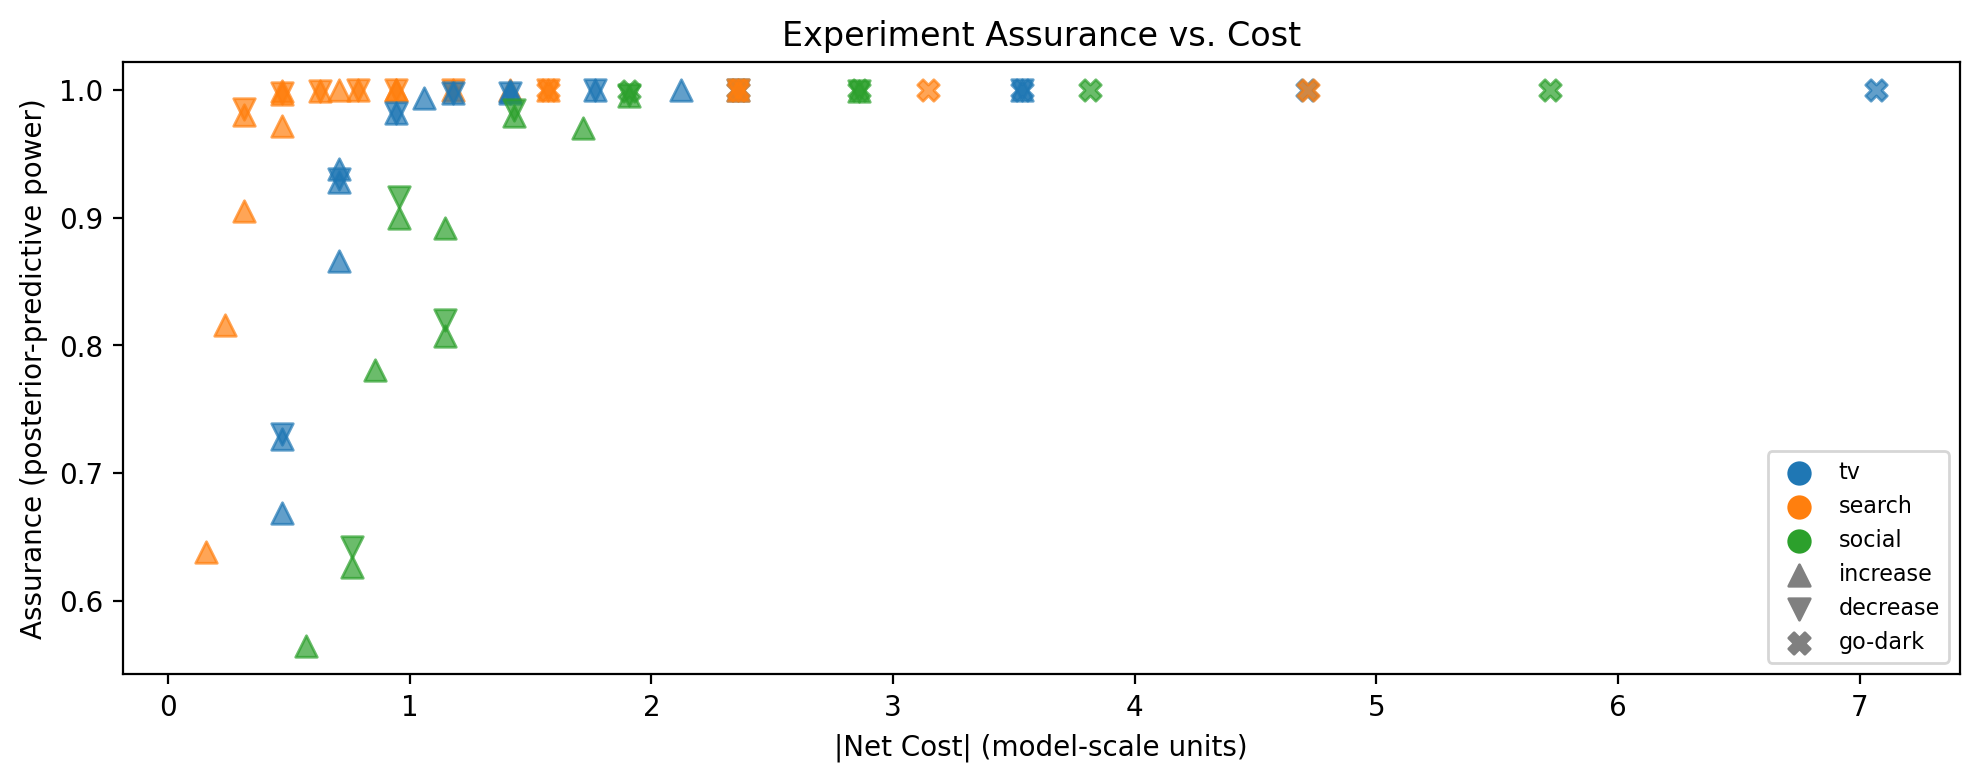

In [12]:
fig, ax = designer.plot_power_cost(
    recommendations, colors=CHANNEL_COLORS, figsize=(FIG_WIDTH, FIG_HEIGHT)
)
plt.show()

**Caption:** Bayesian assurance vs. absolute net cost for all candidate experiments passing the SNR filter. Marker color indicates channel; marker shape indicates spend direction (triangle-up = increase, triangle-down = decrease, X = go-dark).

#### Lift Distributions

Drilling into a single channel, we can inspect the full posterior distribution of predicted lift across different spend changes and experiment durations. Each panel shows a density plot of the cumulative lift — this is the distribution that the assurance calculation integrates over (see [Bayesian Assurance](#bayesian-assurance-posterior-predictive-power)).

The vertical dashed line at zero is the key reference. When the entire distribution sits clearly away from zero (i.e. the HDI does not overlap zero), the predicted signal is large relative to noise for most posterior draws, which translates to high assurance. Conversely, when the distribution straddles zero, many posterior draws imply a lift too small to detect, pulling assurance down. Reading across columns (increasing duration) shows how longer experiments shift the distribution further from zero as the adstock ramp captures more of the steady-state effect.

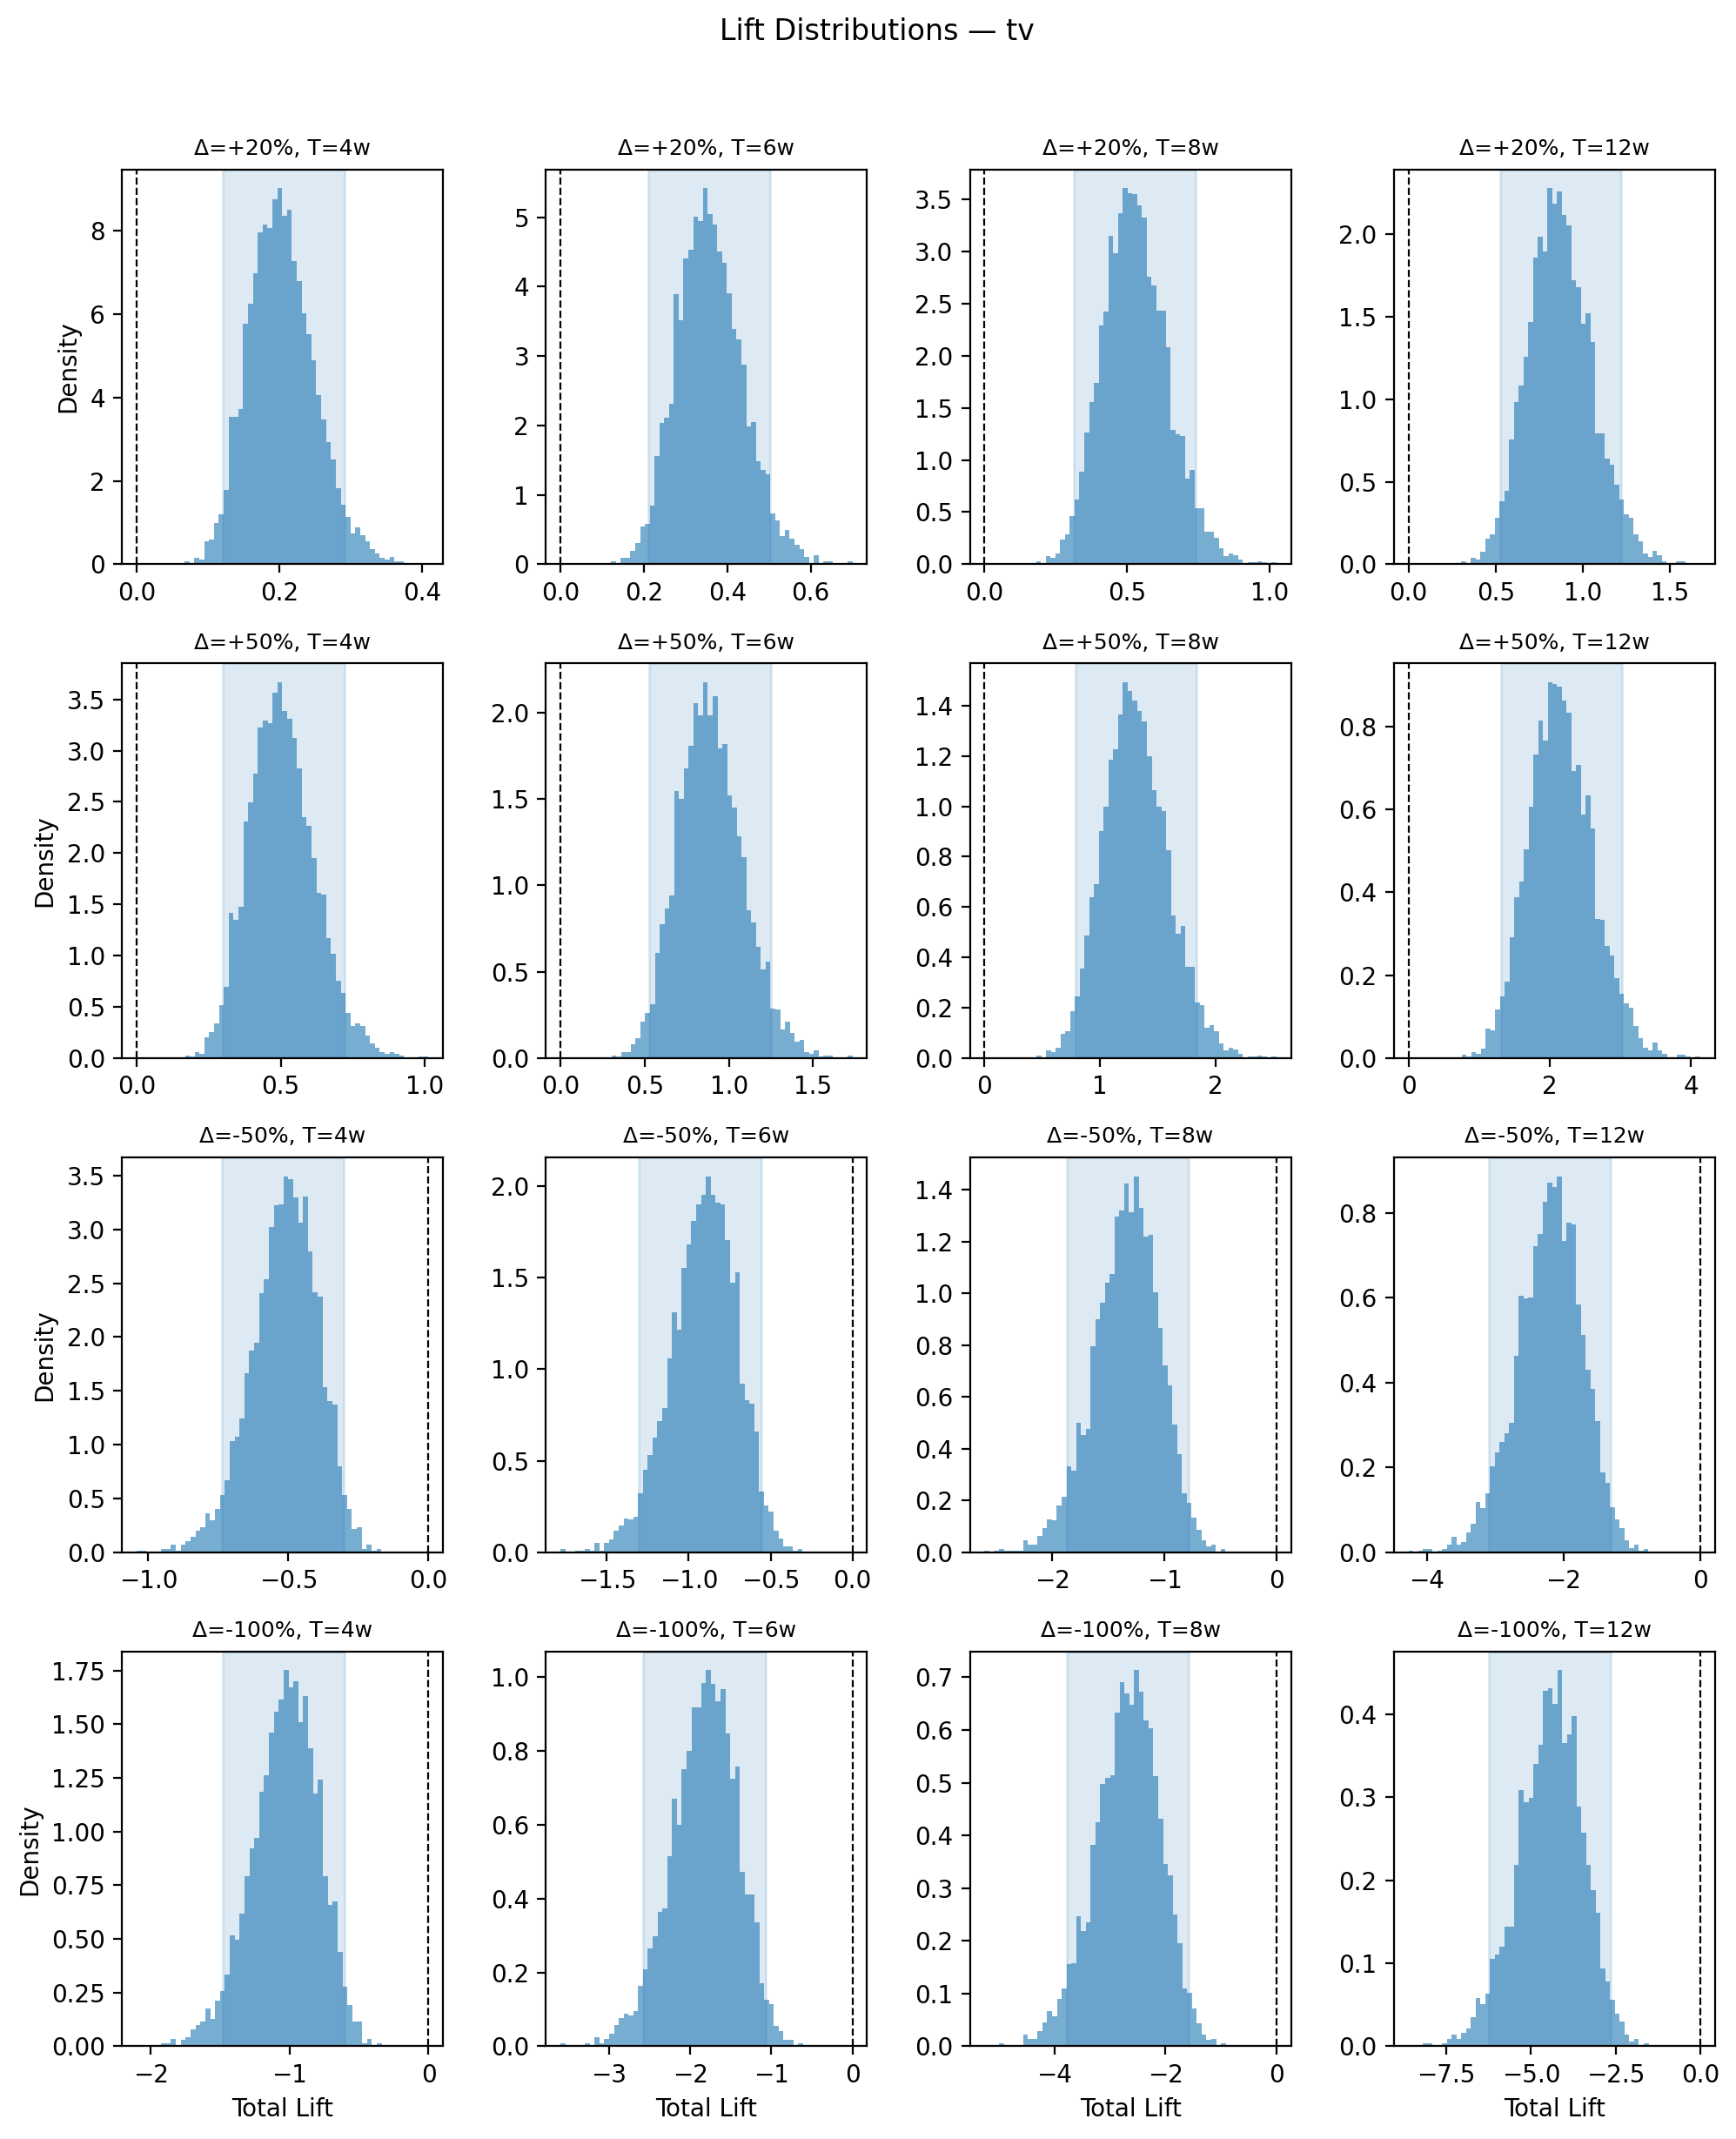

In [13]:
fig, axes = designer.plot_lift_distributions(
    "tv",
    spend_changes=[0.2, 0.5, -0.5, -1.0],
    durations=[4, 6, 8, 12],
    color=CHANNEL_COLORS["tv"],
    figsize=(FIG_WIDTH, FIG_HEIGHT * 3),
)
plt.show()

**Caption:** Posterior distribution of total predicted lift for the TV channel across spend changes (rows) and experiment durations (columns). Shaded region is the 94% HDI; vertical dashed line marks zero lift. Distributions whose HDI excludes zero correspond to high-assurance experiments; those straddling zero indicate the signal may be too small to detect reliably.

#### Adstock Ramp-up

When you change spend on a channel, the adstocked (effective) spend doesn't jump to its new level immediately — it ramps up over several weeks as the geometric decay accumulates the new spend level. The **ramp fraction** measures how much of the full steady-state effect has been captured by week $t$ of the experiment (see [Adstock-Aware Lift Prediction](#adstock-aware-lift-prediction)).

**How to read the plot.** The y-axis is the ramp fraction (0 = no effect yet, 1 = full steady-state reached). Each channel's curve shows how quickly it approaches steady state, with a shaded uncertainty band from the posterior. Channels with fast adstock decay (low $\alpha$, e.g. search) reach 1.0 within a few weeks, while slow-decay channels (high $\alpha$, e.g. TV) may still be well below 1.0 after 12 weeks.

**Why this matters for experiment design:**

- **Minimum duration.** If the ramp fraction for a channel is only 0.6 at your planned experiment length, the experiment will only capture ~60% of the true steady-state effect. This understates the lift, reduces the SNR, and lowers assurance. The plot tells you how long the experiment *needs* to be to see the full signal.
- **Interpreting results.** If you run a 4-week test on a slow-decay channel and observe a small lift, the ramp fraction tells you whether that small lift is genuinely small or simply truncated by insufficient duration.
- **Channel comparison.** Two channels may have similar expected lifts, but if one reaches steady state in 4 weeks and the other needs 12, the faster channel is a better candidate for a short experiment. This is already baked into the assurance and scoring, but the ramp plot makes the mechanism visible.

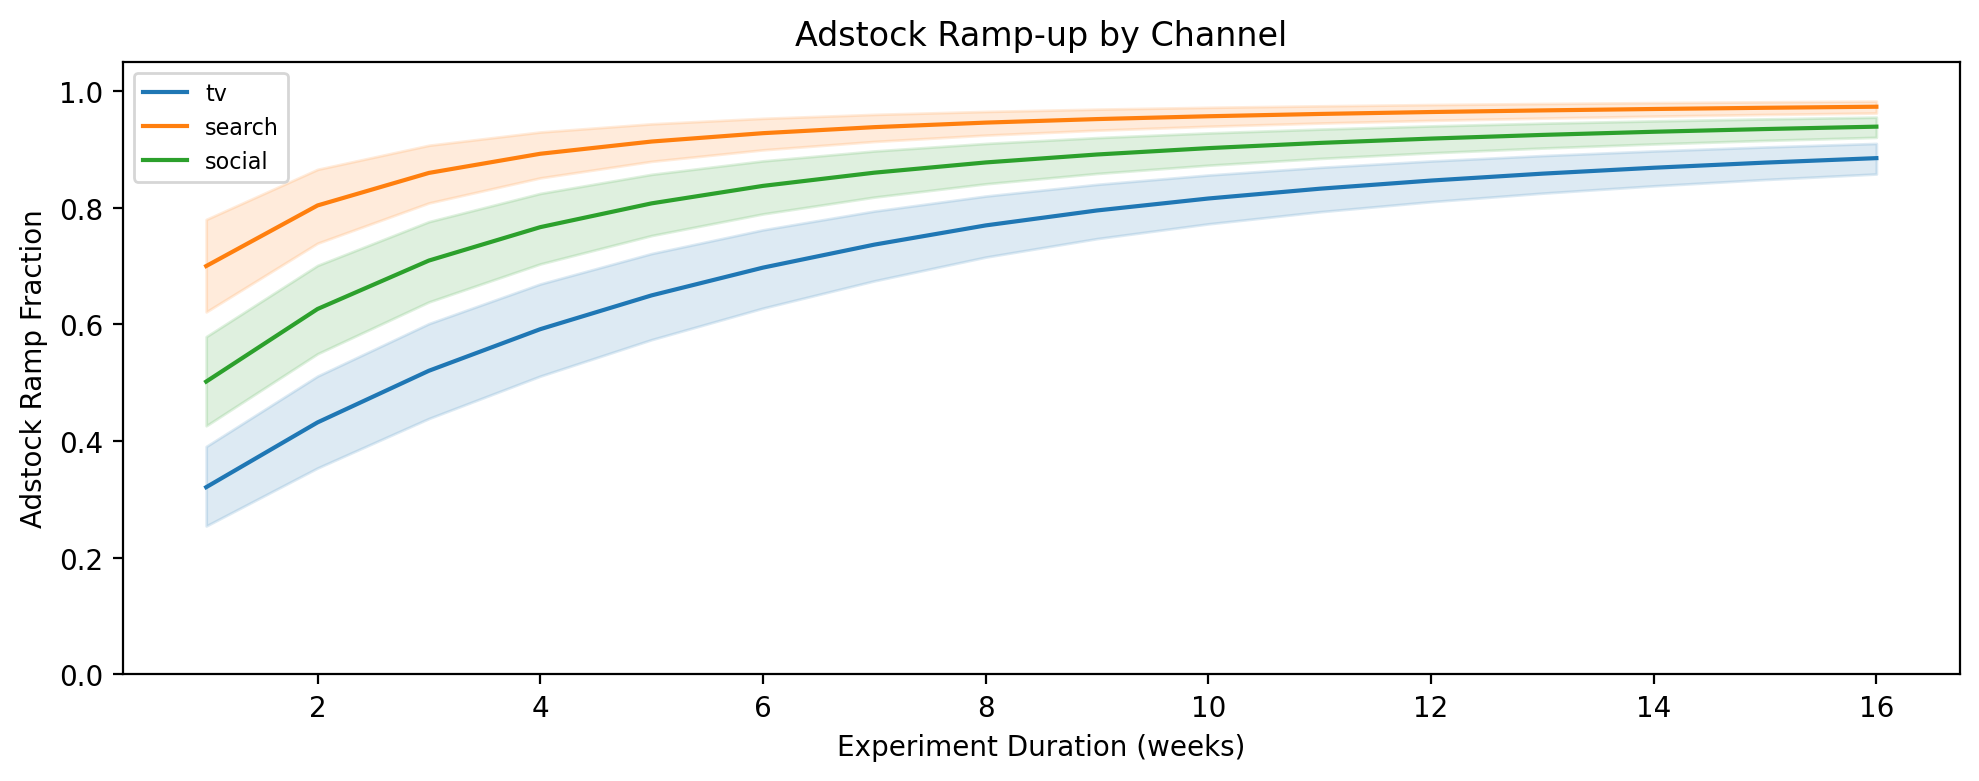

In [14]:
fig, ax = designer.plot_adstock_ramp(
    max_weeks=16, colors=CHANNEL_COLORS, figsize=(FIG_WIDTH, FIG_HEIGHT)
)
plt.show()

**Caption:** Adstock ramp fraction vs. experiment duration for each channel. Shaded band is the 89% posterior interval. Channels with higher adstock α approach steady state more slowly, requiring longer experiments to capture the full effect.

## Identification Safeguards

The workflow above used a well-behaved fixture where all channels have meaningful effects and moderate spend correlation. In practice, two common situations require special handling:

1. **A channel the model believes is ineffective.** If the posterior for a channel's contribution is concentrated near zero, assurance will be low regardless of experiment design. The designer flags these as **null-confirmation candidates** — channels worth testing precisely to confirm they have no effect and justify reallocating budget.

2. **Highly correlated spend between channels.** When two channels' spend moves together (r > 0.7), the model may struggle to separate their individual effects. The posterior could be confidently wrong due to confounding. The designer adds an **identification warning** to the rationale for such channels.

To demonstrate both safeguards, we create a second fixture with deliberate pathologies.

In [15]:
idata_edge = generate_experiment_fixture(
    channels=["tv", "search", "social", "display"],
    true_params={
        "tv": {"lam": 0.5, "beta": 3.0, "alpha": 0.7},
        "search": {"lam": 2.0, "beta": 1.5, "alpha": 0.3},
        "social": {"lam": 1.0, "beta": 0.8, "alpha": 0.5},
        "display": {"lam": 1.0, "beta": 0.01, "alpha": 0.4},
    },
    fit_model=False,
    seed=42,
)

designer_edge = ExperimentDesigner.from_idata(idata_edge)

# Simulate high spend correlation between tv and search (r = 0.85)
channels_edge = designer_edge.channel_columns
corr_matrix = designer_edge._spend_correlation.copy()
corr_matrix.loc["tv", "search"] = 0.85
corr_matrix.loc["search", "tv"] = 0.85
designer_edge._spend_correlation = corr_matrix

In [16]:
recs_edge = designer_edge.recommend(
    spend_changes=[0.2, 0.5, -0.5, -1.0],
    durations=[4, 8],
    min_snr=0.0,
)
recs_edge[:8]

Rank,Channel,Δ Spend,Duration,E[Lift],Lift 94% HDI,SNR,Assurance,Ramp,Score
1,search,+20%/wk,4w,0.41,"[0.27, 0.53]",4.7,0.99,0.90,0.992
2,search,+20%/wk,8w,0.86,"[0.60, 1.13]",7.1,1.00,0.95,0.752
3,tv,-50%/wk,4w,-0.34,"[-0.48, -0.20]",-3.9,0.93,0.59,0.717
4,tv,+50%/wk,4w,0.33,"[0.20, 0.48]",3.9,0.93,0.59,0.716
5,search,-50%/wk,4w,-1.19,"[-1.59, -0.76]",-13.8,1.00,0.88,0.701
6,search,+50%/wk,4w,0.94,"[0.64, 1.21]",10.9,1.00,0.90,0.701
7,tv,+20%/wk,8w,0.35,"[0.21, 0.49]",2.9,0.78,0.77,0.648
8,tv,go-dark,4w,-0.67,"[-0.97, -0.40]",-7.8,1.00,0.59,0.635


**Null-confirmation candidates.** The "display" channel does not appear in the recommendation table — its near-zero beta means predicted lifts are too small to detect. Instead, it is flagged below the table as a null-confirmation candidate, alerting the user that this channel may be worth testing to confirm the model's belief and potentially stop spending on it.

In [17]:
# Show the rationale for a tv recommendation to see the identification warning
tv_recs = [r for r in recs_edge if r.channel == "tv"]
if tv_recs:
    print(tv_recs[0].rationale)

tv is a high-priority test target (uncertainty rank #2) and high spend correlation with search (r = 0.85).
A -50%/wk change for 4 weeks produces an expected total lift of -0.34 (94% HDI: [-0.48, -0.20]) with assurance 0.93.
Adstock ramp fraction 0.59 — net cost: -0.76 (model-scale units).
Caution: tv has high spend correlation (r = 0.85) with other channels, which may indicate identification problems. The model's posterior for this channel could be influenced by confounding. Interpret assurance with care.


**Identification warning.** Because tv and search have a spend correlation of r = 0.85, the rationale includes a "Caution" paragraph warning that the model's posterior for this channel may be influenced by confounding. High assurance on a confounded channel can be misleading — the model may be confidently wrong. This warning reminds the user to verify the model's identification before acting on the recommendation.

## Using with a Fitted MMM

In practice, you'd create the designer directly from a fitted `MMM`:

```python
from pymc_marketing.mmm.multidimensional import MMM
from pymc_marketing.mmm import GeometricAdstock, LogisticSaturation
from pymc_marketing.mmm.experiment_design import ExperimentDesigner

mmm = MMM(
    date_column="date",
    channel_columns=["tv", "search", "social"],
    target_column="revenue",
    adstock=GeometricAdstock(l_max=8),
    saturation=LogisticSaturation(),
)
mmm.fit(X, y)

designer = ExperimentDesigner(mmm)
recommendations = designer.recommend()
```

The designer extracts everything it needs from the fitted model: posterior samples, current spend levels, residual noise, and spend correlations.

## Summary

The `ExperimentDesigner` provides a principled, posterior-aware approach to lift test planning. Key takeaways:

- **No guessing required.** Unlike traditional power analysis, the designer uses the MMM's posterior to derive a full distribution of predicted lifts for every candidate experiment — eliminating the need to specify an expected effect size up front.
- **Adstock-aware predictions.** Lift predictions account for the geometric adstock ramp, so short experiments on slow-decaying channels are correctly penalised.
- **Bayesian assurance with autocorrelation correction.** Posterior-predictive power honestly reflects model uncertainty. The measurement noise model accounts for AR(1) autocorrelation in the MMM residuals, producing more conservative and realistic assurance estimates than the IID assumption.
- **Simple, transparent scoring.** The default score balances assurance and cost efficiency — two dimensions that are easy to interpret and hard to game. The relative weights can be adjusted via `score_weights`.
- **Null-confirmation candidates.** Channels the model believes have near-zero effect are flagged separately, ensuring they aren't silently ignored. Confirming a channel is ineffective can be just as valuable as quantifying its contribution.
- **Identification warnings.** Channels with high spend correlation are flagged in the recommendation rationale, alerting users that the posterior — and therefore assurance — may be influenced by confounding.
- **Diagnostic visualisations.** Power-vs-cost plots, lift distributions, and adstock ramp charts help you build intuition and communicate recommendations to stakeholders.

:::{warning}
**Causal identifiability matters.** The designer recommends experiments based on the MMM's posterior, but the posterior is only as good as the model. If the model has identifiability issues (e.g. highly correlated channels, confounding from unmeasured variables), the predicted lifts and assurance values may be misleading. Assurance is conditional on the model being reasonably well-identified — a confidently wrong posterior will produce confidently high assurance. The designer flags high spend correlation automatically, but users should always review model diagnostics (posterior predictive checks, prior sensitivity) before acting on recommendations.

- **Run one lift test at a time.** Simultaneous experiments on multiple channels confound each other, making it impossible to attribute the observed effect to a single channel. If you must test multiple channels, stagger them with sufficient washout periods between experiments.
- **Plan for sufficient duration.** The adstock ramp fraction tells you whether the experiment is long enough to capture the full effect. Cutting an experiment short because early results look promising (or disappointing) introduces bias.
:::

:::{note}
**This is experimental functionality — we want your feedback.** The `ExperimentDesigner` is under active development. We are keen to hear how you use it, what works, and what should change. Topics we are especially interested in:

- Should we replace the weighted scoring with a principled information-gain objective (e.g. Fisher Information)?
- Would geo-level experiment design be valuable for your use case?
- How do you handle null-confirmation in your current workflow?

Please open an issue or start a discussion on the [PyMC-Marketing GitHub](https://github.com/pymc-labs/pymc-marketing). If you'd like hands-on support with lift test planning, calibration, or MMM development, [PyMC Labs](https://www.pymc-labs.com) offers consulting and mentoring.
:::